In [19]:
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Load the news dataset
news_df = pd.read_csv('../data/raw_analyst_ratings.csv')

# Load the stock price dataset
stock_df = pd.read_csv('../data/TSLA_historical_data.csv')

In [11]:
# --- Step 1: Parse all datetime strings in the news file robustly ---
# Remove timezone and extract just the date part
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce', utc=True).dt.date

# Drop rows where date conversion failed
news_df = news_df.dropna(subset=['date'])

# --- Step 2: Convert stock 'Date' column to datetime.date as well ---
stock_df['Date'] = pd.to_datetime(stock_df['Date'], errors='coerce').dt.date

In [12]:
overlap_dates = set(news_df['date']) & set(stock_df['Date'])
print(f"Number of overlapping dates: {len(overlap_dates)}")


Number of overlapping dates: 2222


In [14]:
# Define a function to get sentiment polarity score
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

# Apply sentiment analysis to the 'headline' column
news_df['sentiment_score'] = news_df['headline'].apply(get_sentiment)

# Optional: classify sentiment into categories
def classify_sentiment(score):
    if score > 0:
        return 'positive'
    elif score < 0:
        return 'negative'
    else:
        return 'neutral'

news_df['sentiment_category'] = news_df['sentiment_score'].apply(classify_sentiment)

# View the first few rows with sentiment
print(news_df[['headline', 'sentiment_score', 'sentiment_category']].head())

                                            headline  sentiment_score  \
0            Stocks That Hit 52-Week Highs On Friday              0.0   
1         Stocks That Hit 52-Week Highs On Wednesday              0.0   
2                      71 Biggest Movers From Friday              0.0   
3       46 Stocks Moving In Friday's Mid-Day Session              0.0   
4  B of A Securities Maintains Neutral on Agilent...              0.0   

  sentiment_category  
0            neutral  
1            neutral  
2            neutral  
3            neutral  
4            neutral  


In [15]:
# Calculate daily returns as percentage change of 'Close' price
stock_df = stock_df.sort_values('Date')  # Make sure sorted by date
stock_df['daily_return'] = stock_df['Close'].pct_change() * 100

# Drop the first row with NaN daily_return
stock_df = stock_df.dropna(subset=['daily_return'])


In [16]:
# Group news sentiment scores by date (average polarity per day)
daily_sentiment = news_df.groupby('date')['sentiment_score'].mean().reset_index()

# Rename column for clarity
daily_sentiment.rename(columns={'date': 'Date'}, inplace=True)


In [17]:
# Merge stock returns with daily sentiment on Date
merged_df = pd.merge(stock_df, daily_sentiment, on='Date', how='inner')

print(merged_df[['Date', 'daily_return', 'sentiment_score']].head())

         Date  daily_return  sentiment_score
0  2011-04-28      2.141819         0.045455
1  2011-04-29     -0.216917         0.166667
2  2011-05-02     -0.543478        -0.009259
3  2011-05-03     -2.112955         0.000000
4  2011-05-05     -0.936646         0.000000


In [18]:
correlation = merged_df['daily_return'].corr(merged_df['sentiment_score'])
print(f"Pearson correlation between daily stock returns and average daily sentiment: {correlation:.4f}")


Pearson correlation between daily stock returns and average daily sentiment: 0.0207


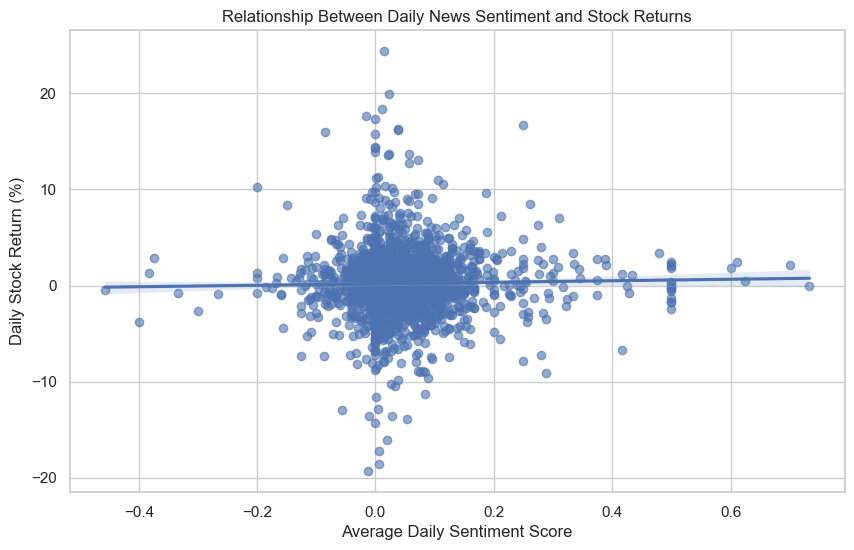

In [20]:
# Set plot style
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))

# Scatter plot with regression line
sns.regplot(x='sentiment_score', y='daily_return', data=merged_df, scatter_kws={'alpha':0.6})

plt.title('Relationship Between Daily News Sentiment and Stock Returns')
plt.xlabel('Average Daily Sentiment Score')
plt.ylabel('Daily Stock Return (%)')

plt.show()